In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_v4.csv')

In [70]:
df.shape

(3499, 18)

In [71]:
df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,vatika gurgaon,sector 83,1.18,6801.00,3,3,2,14.0,relatively new,1612.0,0,0,0,0,0,1,16.0
1,flat,emaar digihomes,sector 62,4.00,14870.99,3,3,3,18.0,new,2353.0,1,0,0,0,0,0,40.0
2,flat,ss the leaf,sector 85,1.10,6317.99,2,2,3+,3.0,relatively new,1459.0,0,0,0,1,0,1,117.0
3,flat,tarc maceo,sector 91,0.89,6338.99,2,2,3+,9.0,relatively new,1297.0,0,0,0,0,1,0,9.0
4,flat,rwa,sector 7,0.48,6000.00,3,2,1,1.0,new,889.0,0,0,0,0,0,1,12.0


In [72]:
df.isnull().sum()

property_type      0
society            0
sector             0
price_in_cr        0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
servant room       0
study room         0
pooja room         0
store room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [73]:
# temporarily drop society and price_per_sqft as they will not be something that the use will be choosing specifically

train_df = df.drop(columns = ['society', 'price_per_sqft'])

In [74]:
train_df.head()

,property_type,sector,price_in_cr,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,sector 83,1.18,3,3,2,14.0,relatively new,1612.0,0,0,0,0,0,1,16.0
1,flat,sector 62,4.00,3,3,3,18.0,new,2353.0,1,0,0,0,0,0,40.0
2,flat,sector 85,1.10,2,2,3+,3.0,relatively new,1459.0,0,0,0,1,0,1,117.0
3,flat,sector 91,0.89,2,2,3+,9.0,relatively new,1297.0,0,0,0,0,1,0,9.0
4,flat,sector 7,0.48,3,2,1,1.0,new,889.0,0,0,0,0,0,1,12.0


<Axes: >

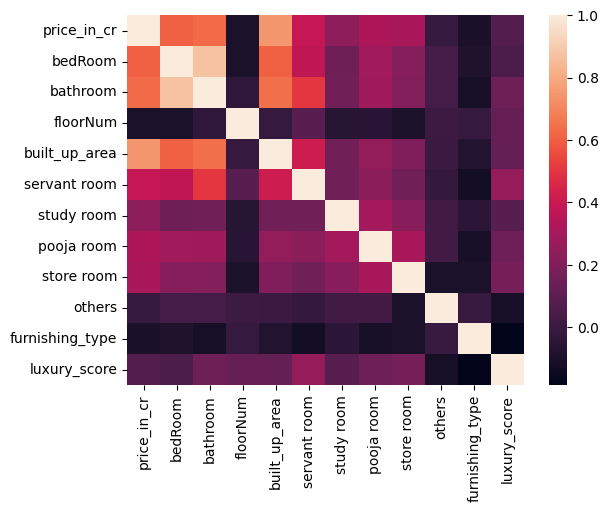

In [75]:
sns.heatmap(train_df.select_dtypes(include = 'number').corr())

In [76]:
train_df.select_dtypes(include = 'number').corr()['price_in_cr'].sort_values(ascending=False)

price_in_cr        1.000000
built_up_area      0.749261
bathroom           0.631117
bedRoom            0.602365
servant room       0.385131
pooja room         0.324182
store room         0.307983
study room         0.236859
luxury_score       0.073037
others            -0.015822
floorNum          -0.098334
furnishing_type   -0.105118
Name: price_in_cr, dtype: float64

- as per the corr matrix, strong correlation of price with built up area, bathroom, bedoom 
- but there is potential risk of multicollinearity among these features
- similary potentiall multicollinearity between servant room, store room and study room
- furnishing type is showing negative correlation because of notation that we used after kmean results 
    -#1 --> unfurnished
    -#2 --> furnished
    -#0 --> sem-furnished
    - will replace these

In [77]:
df['furnishing_type'] = df['furnishing_type'].replace({1:0, 0:1})

In [78]:
train_df['furnishing_type'] = train_df['furnishing_type'].replace({1:0, 0:1})

# now furnishing types are: 0--> unfurnished, 1--> semi-furnished, 2 --> furnsished

In [79]:
train_df.select_dtypes(include = 'number').corr()['price_in_cr'].sort_values(ascending=False)

price_in_cr        1.000000
built_up_area      0.749261
bathroom           0.631117
bedRoom            0.602365
servant room       0.385131
pooja room         0.324182
store room         0.307983
study room         0.236859
furnishing_type    0.213642
luxury_score       0.073037
others            -0.015822
floorNum          -0.098334
Name: price_in_cr, dtype: float64

- based correlation with price, 
- cols in question: 
    - numerical--> luxury_score, others, floorNum
    - categorical --> property_type, sector, agePossesion

### luxury_score column
- bin the luxury column into budget, semi-luxury and luxury

<Axes: xlabel='luxury_score'>

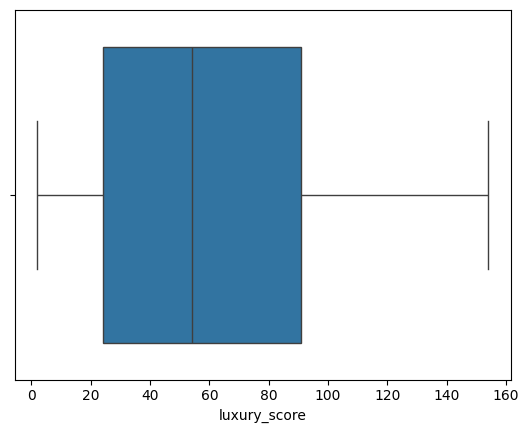

In [80]:
sns.boxplot(x = df['luxury_score'])

In [81]:
def luxury_bins(score):
    if score <= 40:
        return 'budget'
    elif score > 40 and score <= 100:
        return 'semi-luxury'
    elif score > 100:
        return 'luxury'

In [82]:
train_df['luxury_category'] = train_df['luxury_score'].apply(luxury_bins)

In [83]:
train_df['luxury_category'].value_counts()

luxury_category
semi-luxury    1466
budget         1298
luxury          735
Name: count, dtype: int64

<Axes: xlabel='luxury_category', ylabel='price_in_cr'>

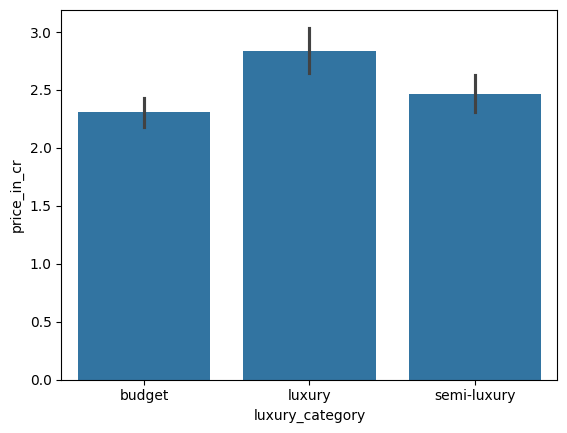

In [84]:
sns.barplot(x = train_df['luxury_category'], y = train_df['price_in_cr'], estimator='mean')

In [85]:
train_df.head()

,property_type,sector,price_in_cr,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 83,1.18,3,3,2,14.0,relatively new,1612.0,0,0,0,0,0,0,16.0,budget
1,flat,sector 62,4.00,3,3,3,18.0,new,2353.0,1,0,0,0,0,1,40.0,budget
2,flat,sector 85,1.10,2,2,3+,3.0,relatively new,1459.0,0,0,0,1,0,0,117.0,luxury
3,flat,sector 91,0.89,2,2,3+,9.0,relatively new,1297.0,0,0,0,0,1,1,9.0,budget
4,flat,sector 7,0.48,3,2,1,1.0,new,889.0,0,0,0,0,0,0,12.0,budget


### floorNum
- make bins from floorNum into high-rise, medium-rise or low-rise
    - 0-3 floor --> low-rise
    - 3-10 fllor --> medium rise
    - 10 above --> high-rise

<Axes: xlabel='floorNum'>

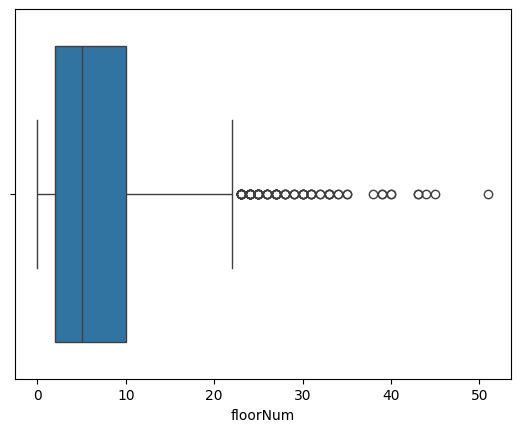

In [86]:
sns.boxplot(x = train_df['floorNum'])

In [87]:
def floor_bins(floorNum):
    if floorNum <= 3:
        return 'low-rise'
    elif floorNum > 3 and floorNum <= 10:
        return 'medium-rise'
    elif floorNum > 10:
        return 'high-rise'

In [88]:
train_df['floor_category'] = train_df['floorNum'].apply(floor_bins)

In [89]:
train_df.head()

,property_type,sector,price_in_cr,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 83,1.18,3,3,2,14.0,relatively new,1612.0,0,0,0,0,0,0,16.0,budget,high-rise
1,flat,sector 62,4.00,3,3,3,18.0,new,2353.0,1,0,0,0,0,1,40.0,budget,high-rise
2,flat,sector 85,1.10,2,2,3+,3.0,relatively new,1459.0,0,0,0,1,0,0,117.0,luxury,low-rise
3,flat,sector 91,0.89,2,2,3+,9.0,relatively new,1297.0,0,0,0,0,1,1,9.0,budget,medium-rise
4,flat,sector 7,0.48,3,2,1,1.0,new,889.0,0,0,0,0,0,0,12.0,budget,low-rise


<Axes: xlabel='floor_category', ylabel='price_in_cr'>

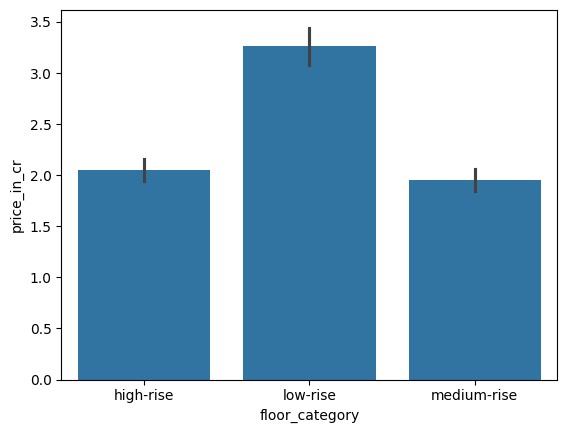

In [90]:
sns.barplot(x = train_df['floor_category'], y = train_df['price_in_cr'], estimator='mean')

In [91]:
# drop luxury_score and floorNum

train_df.drop(columns=['luxury_score', 'floorNum'], inplace = True)

In [92]:
train_df.head()

,property_type,sector,price_in_cr,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,0,0,0,0,budget,high-rise
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,0,0,0,1,budget,high-rise
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,0,0,1,0,0,luxury,low-rise
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,0,0,1,1,budget,medium-rise
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,0,0,0,0,budget,low-rise


### Feature selection

Encoding categorical features

In [93]:
from sklearn.preprocessing import OrdinalEncoder

#copy of original data
data_label_encoded = train_df.copy()

categorical_columns = train_df.select_dtypes(include = 'object').columns

# apply label encoding
for col in categorical_columns:
    encoder = OrdinalEncoder()
    data_label_encoded[col] = encoder.fit_transform(data_label_encoded[[col]])
    print(encoder.categories_)



[array(['flat', 'house'], dtype=object)]
[array(['sector 1', 'sector 10', 'sector 102', 'sector 103', 'sector 104',
       'sector 105', 'sector 106', 'sector 107', 'sector 108',
       'sector 109', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 30', 'sector 31', 'sector 33',
       'sector 36', 'sector 37', 'sector 38', 'sector 39', 'sector 3a',
       'sector 4', 'sector 40', 'sector 41', 'sector 43', 'sector 45',
       'sector 46', 'sector 47', 'sector 48', 'sector 49', 'sector 5',
       'sector 50', 'sector 51', 'sector 52', 'sector 53', 'sector 54',
       'sector 55', 'sector 56', 'sector 57', 'sector 58', 'sector 59',
       'sector 6', 'sector 60', 'sector 61', 'sector 62', 'sector 63',
       'sector 65', 'sector 66', 'sector 6

C:\Users\apaks\AppData\Local\Temp\ipykernel_10904\1623257811.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = train_df.select_dtypes(include = 'object').columns


In [94]:
data_label_encoded

,property_type,sector,price_in_cr,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_category,floor_category
0,0.0,82.0,1.18,3,3,2.0,2.0,1612.0,0,0,0,0,0,0,0.0,0.0
1,0.0,61.0,4.00,3,3,3.0,0.0,2353.0,1,0,0,0,0,1,0.0,0.0
2,0.0,84.0,1.10,2,2,4.0,2.0,1459.0,0,0,0,1,0,0,1.0,1.0
3,0.0,90.0,0.89,2,2,4.0,2.0,1297.0,0,0,0,0,1,1,0.0,2.0
4,0.0,68.0,0.48,3,2,1.0,0.0,889.0,0,0,0,0,0,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3494,0.0,3.0,1.35,3,3,4.0,2.0,1627.0,0,1,0,0,0,1,1.0,1.0
3495,1.0,25.0,15.50,5,6,4.0,3.0,4518.0,1,1,1,1,0,0,1.0,1.0
3496,0.0,8.0,2.10,2,2,2.0,4.0,1255.0,0,0,0,0,0,0,2.0,1.0
3497,0.0,4.0,1.75,3,4,4.0,2.0,2082.0,1,0,0,0,0,0,2.0,0.0


In [95]:
# spliting X and y

X_label = data_label_encoded.drop('price_in_cr', axis = 1)
y_label = data_label_encoded['price_in_cr']

In [96]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_category,floor_category
0,0.0,82.0,3,3,2.0,2.0,1612.0,0,0,0,0,0,0,0.0,0.0
1,0.0,61.0,3,3,3.0,0.0,2353.0,1,0,0,0,0,1,0.0,0.0
2,0.0,84.0,2,2,4.0,2.0,1459.0,0,0,0,1,0,0,1.0,1.0
3,0.0,90.0,2,2,4.0,2.0,1297.0,0,0,0,0,1,1,0.0,2.0
4,0.0,68.0,3,2,1.0,0.0,889.0,0,0,0,0,0,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3494,0.0,3.0,3,3,4.0,2.0,1627.0,0,1,0,0,0,1,1.0,1.0
3495,1.0,25.0,5,6,4.0,3.0,4518.0,1,1,1,1,0,0,1.0,1.0
3496,0.0,8.0,2,2,2.0,4.0,1255.0,0,0,0,0,0,0,2.0,1.0
3497,0.0,4.0,3,4,4.0,2.0,2082.0,1,0,0,0,0,0,2.0,0.0


In [97]:
y_label

0        1.18
1        4.00
2        1.10
3        0.89
4        0.48
        ...  
3494     1.35
3495    15.50
3496     2.10
3497     1.75
3498     0.72
Name: price_in_cr, Length: 3499, dtype: float64

### 1. Correlation analysis

<Axes: >

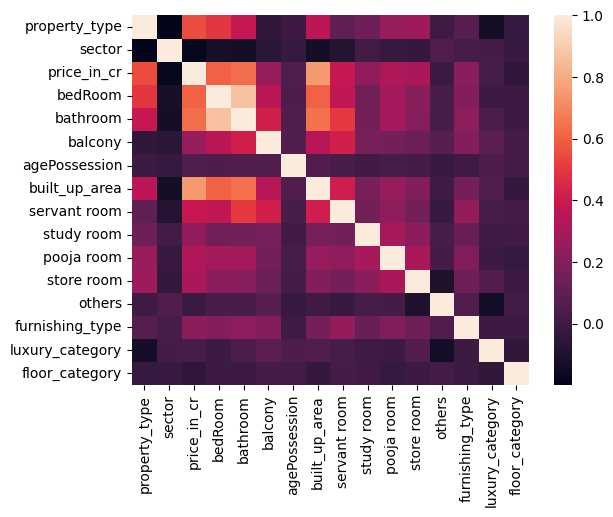

In [98]:
sns.heatmap(data_label_encoded.corr())

In [99]:
data_label_encoded.corr()

,property_type,sector,price_in_cr,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_category,floor_category
property_type,1.000000,-0.198796,0.551495,0.496826,0.388924,-0.041202,-0.006610,0.354418,0.096585,0.141260,0.255263,0.270609,-0.000875,0.068338,-0.128736,-0.028892
sector,-0.198796,1.000000,-0.176090,-0.125512,-0.128988,-0.064688,-0.027150,-0.134768,-0.082344,0.013390,-0.022070,-0.034036,0.051224,0.028731,0.017243,-0.020144
price_in_cr,0.551495,-0.176090,1.000000,0.602365,0.631117,0.253734,0.052107,0.749261,0.385131,0.236859,0.324182,0.307983,-0.015822,0.213642,0.022695,-0.044534
bedRoom,0.496826,-0.125512,0.602365,1.000000,0.873050,0.353020,0.048951,0.602204,0.371833,0.144991,0.289187,0.215726,0.031599,0.200209,-0.002848,-0.010248
bathroom,0.388924,-0.128988,0.631117,0.873050,1.000000,0.421655,0.053585,0.641588,0.503771,0.155042,0.285131,0.205124,0.031845,0.232007,0.038726,-0.004665
balcony,-0.041202,-0.064688,0.253734,0.353020,0.421655,1.000000,0.055178,0.340980,0.422809,0.164509,0.159430,0.129742,0.080181,0.202053,0.083408,0.020996
agePossession,-0.006610,-0.027150,0.052107,0.048951,0.053585,0.055178,1.000000,0.052250,0.030967,0.009558,0.024300,0.018957,-0.020431,0.000024,0.048375,0.021142
built_up_area,0.354418,-0.134768,0.749261,0.602204,0.641588,0.340980,0.052250,1.000000,0.414358,0.162039,0.253601,0.195545,-0.001275,0.158539,0.052513,-0.031664
servant room,0.096585,-0.082344,0.385131,0.371833,0.503771,0.422809,0.030967,0.414358,1.000000,0.154853,0.235248,0.156599,-0.019631,0.247146,0.024667,0.016961
study room,0.141260,0.013390,0.236859,0.144991,0.155042,0.164509,0.009558,0.162039,0.154853,1.000000,0.294703,0.221043,0.021946,0.127397,0.002439,0.010947


In [100]:
feature_importance_df1 = data_label_encoded.corr()['price_in_cr'].drop(index = 'price_in_cr').to_frame().reset_index().rename(columns = {'index': 'feature', 'price_in_cr': 'corr_coef'})       # correlation of price with all the other features and convert them to a dataframe feature_importance_df1

In [101]:
feature_importance_df1

,feature,corr_coef
0,property_type,0.551495
1,sector,-0.176090
2,bedRoom,0.602365
3,bathroom,0.631117
4,balcony,0.253734
5,agePossession,0.052107
6,built_up_area,0.749261
7,servant room,0.385131
8,study room,0.236859
9,pooja room,0.324182


### 2. Random Forest Feature Selection

In [102]:
from sklearn.ensemble import RandomForestRegressor

rf_label = RandomForestRegressor(n_estimators= 100, random_state=42)
rf_label.fit(X_label, y_label)

# extract feature importance based on RandomForestRegressor

feature_importance_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
    })

In [103]:
feature_importance_df2

,feature,rf_importance
0,property_type,0.099448
1,sector,0.099470
2,bedRoom,0.024625
3,bathroom,0.030815
4,balcony,0.011770
5,agePossession,0.015418
6,built_up_area,0.653796
7,servant room,0.016517
8,study room,0.007307
9,pooja room,0.004747


### 3. Gradient Boosting Feature Importance

In [104]:
from sklearn.ensemble import GradientBoostingRegressor

gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

feature_importance_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
    })

In [105]:
feature_importance_df3.sort_values('gb_importance', ascending=False)

,feature,gb_importance
6,built_up_area,0.687735
0,property_type,0.100337
1,sector,0.097126
2,bedRoom,0.033400
3,bathroom,0.030735
7,servant room,0.022773
10,store room,0.009201
5,agePossession,0.004812
12,furnishing_type,0.004035
14,floor_category,0.003470


### 4. Permutation Importance

In [106]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state= 42)

# train a random forrest regressor on encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# calculate permutation importance
perm_importance = permutation_importance(estimator=rf_label, X = X_test_label, y = y_test_label, n_repeats = 30, random_state=42)

feature_importance_df4 = pd.DataFrame({
    'feature' : X_label.columns,
    'perm_importance': perm_importance.importances_mean
})

In [107]:
feature_importance_df4.sort_values(by= 'perm_importance', ascending = False)

,feature,perm_importance
6,built_up_area,0.706293
0,property_type,0.203119
1,sector,0.115916
7,servant room,0.013848
5,agePossession,0.007218
9,pooja room,0.006310
14,floor_category,0.005664
8,study room,0.004088
3,bathroom,0.004016
12,furnishing_type,0.002489


### 5. LASSO

In [108]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# standardize the features as we are trying linear model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# train lasso model
lasso = Lasso(alpha=0.01, random_state = 42)
lasso.fit(X_scaled, y_label)

feature_importance_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
})


In [109]:
feature_importance_df5.sort_values(by = 'lasso_coeff', ascending=False)

,feature,lasso_coeff
6,built_up_area,1.430978
0,property_type,0.774014
3,bathroom,0.455884
10,store room,0.192643
8,study room,0.164129
12,furnishing_type,0.146226
7,servant room,0.108559
9,pooja room,0.080288
13,luxury_category,0.046041
5,agePossession,0.034832


- sector is show less importance which is not correct. This is happening because we are using ordinal encoding which influences the linear models

### 6. Recursive Feature Elimination

In [110]:
from sklearn.feature_selection import RFE

# base model --> RandomForest
rf = RandomForestRegressor()

# apply RFE
selector_label = RFE(estimator=rf, n_features_to_select=X_label.shape[1], step= 1)     
selector_label = selector_label.fit(X_label, y_label)

# get the selected feature based on RFE
selected_features = X_label.columns[selector_label.support_]

# get the coefficient for the selected features
selected_coefficient = selector_label.estimator_.feature_importances_

feature_importance_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficient
})



In [111]:
feature_importance_df6.sort_values(by = 'rfe_score', ascending=False)

,feature,rfe_score
6,built_up_area,0.648805
0,property_type,0.104397
1,sector,0.099768
3,bathroom,0.030282
2,bedRoom,0.021818
7,servant room,0.017719
5,agePossession,0.014789
4,balcony,0.012219
12,furnishing_type,0.009424
10,store room,0.008160


### 7. Linear Regression

In [112]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_scaled, y_label)

feature_importance_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'lr_coeffs': lr.coef_
})


In [113]:
feature_importance_df7.sort_values(by= 'lr_coeffs', ascending=False)

,feature,lr_coeffs
6,built_up_area,1.438743
0,property_type,0.790816
3,bathroom,0.535496
10,store room,0.196509
8,study room,0.171214
12,furnishing_type,0.155581
7,servant room,0.109665
9,pooja room,0.085306
13,luxury_category,0.054188
5,agePossession,0.044998


- Linear Regrssion method and Lasso are not very relaiable techniques as they are linear models and ordinal encoding is not ideal for linear models. 

Merge all the feature_importance_df from difference techniques

In [114]:
final_feature_importance_df = feature_importance_df1.merge(feature_importance_df2, on='feature').merge(feature_importance_df3, on='feature').merge(feature_importance_df4, on='feature').merge(feature_importance_df5, on='feature').merge(feature_importance_df6, on='feature').merge(feature_importance_df7, on='feature').set_index('feature')

Normalising all the values in final_feature_importance_df

In [115]:
final_feature_importance_df = final_feature_importance_df.divide(final_feature_importance_df.sum(axis=0), axis = 1)       #sum of all the values in each column and divide each value in the column with the sum

Averaging all the feature imporatance for all the features from all the techniques

In [116]:
final_feature_importance_df[['rf_importance', 'gb_importance', 'perm_importance', 'rfe_score']].mean(axis = 1).sort_values(ascending=False)

feature
built_up_area      0.661976
property_type      0.123322
sector             0.101071
bathroom           0.023893
bedRoom            0.020338
servant room       0.017475
agePossession      0.010435
store room         0.006993
balcony            0.006739
floor_category     0.006260
furnishing_type    0.006140
study room         0.005341
pooja room         0.004258
luxury_category    0.004119
others             0.001637
dtype: float64

- At this point, we can possibly drop study room, pooja room and others. 
- Let's try Random Forest on complete data with and without these columns and check if the score improves

In [117]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_category,floor_category
0,0.0,82.0,3,3,2.0,2.0,1612.0,0,0,0,0,0,0,0.0,0.0
1,0.0,61.0,3,3,3.0,0.0,2353.0,1,0,0,0,0,1,0.0,0.0
2,0.0,84.0,2,2,4.0,2.0,1459.0,0,0,0,1,0,0,1.0,1.0
3,0.0,90.0,2,2,4.0,2.0,1297.0,0,0,0,0,1,1,0.0,2.0
4,0.0,68.0,3,2,1.0,0.0,889.0,0,0,0,0,0,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3494,0.0,3.0,3,3,4.0,2.0,1627.0,0,1,0,0,0,1,1.0,1.0
3495,1.0,25.0,5,6,4.0,3.0,4518.0,1,1,1,1,0,0,1.0,1.0
3496,0.0,8.0,2,2,2.0,4.0,1255.0,0,0,0,0,0,0,2.0,1.0
3497,0.0,4.0,3,4,4.0,2.0,2082.0,1,0,0,0,0,0,2.0,0.0


In [118]:
# random forest on complete data
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators= 100, random_state=42)
scores = cross_val_score(rf, X_label, y_label, cv = 5, scoring='r2')

print(scores.mean())

0.8200807430808832


In [119]:
# random forest on data without study room, pooja room and others
rf = RandomForestRegressor(n_estimators= 100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns = ['study room', 'pooja room', 'others']), y_label, cv = 5, scoring= 'r2')
print(scores.mean())

0.8203437636197082


- Clearly, score has slightly gone up after removing these columns. Therefore removing them from the final dataset

In [120]:
X_label.drop(columns = ['study room', 'pooja room', 'others'], inplace = True)

In [121]:
X_label['price'] = y_label

In [122]:
X_label.to_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_v5.csv', index = False)

In [123]:
train_df.head()

,property_type,sector,price_in_cr,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,0,0,0,0,budget,high-rise
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,0,0,0,1,budget,high-rise
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,0,0,1,0,0,luxury,low-rise
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,0,0,1,1,budget,medium-rise
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,0,0,0,0,budget,low-rise


In [124]:
# save the file without encoded data

In [125]:
# rename price column and drop study room. pooja room, others column

train_df.rename(columns = {'price_in_cr': 'price'}, inplace = True)
train_df.drop(columns = ['study room', 'pooja room', 'others'], inplace = True)

In [126]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,0,budget,high-rise
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,1,budget,high-rise
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,1,0,luxury,low-rise
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,1,budget,medium-rise
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,0,budget,low-rise


In [127]:
# change furnishing type notation

train_df['furnishing_type'] = train_df['furnishing_type'].apply(lambda x: 'unfurnished' if x == 0 
                                  else 'semifurnished' if x == 1 
                                  else 'furnished')

In [128]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,unfurnished,budget,high-rise
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,semifurnished,budget,high-rise
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,1,unfurnished,luxury,low-rise
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,semifurnished,budget,medium-rise
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,unfurnished,budget,low-rise


In [129]:
# save the file

train_df.to_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_post_feature_selection.csv', index = False)